# 📖 Bible Reading Progress Tracker - Data Exploration

**Purpose**   
Exploratory Data Analysis of manually reviewed WhatsApp messages from a Bible Reading Group.

**Data Source**  
`reviewed_messages.csv` — manually labeled: each message has been reviewed and assigned:
- `report` — a reading progress report
- `not report` — anything else (system messsages, discussion, general chat)


| # | Section | Description |
|---|---------|-------------|
| 1 | **Setup** | Imports, paths, plot defaults |
| 2 | **Load Data** | Read CSV, parse timestamps, label overview |
| 3 | **Basic Statistics** | Message volume, sender activity, temporal patterns |
| 4 | **Pattern Analysis** | Length, member engagement, consistency |
| 5 | **Temporal Trends** | Monthly volume, day-of-week rhythm, active members |
| 6 | **Export** | Save filtered datasets for downstream tasks |

---
## 0. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pathlib import Path

from config.settings import PROCESSED_DIR

warnings.filterwarnings('ignore')

# ── Paths ───────────────────────────────────────────────────────────────────
DATA_PATH = PROCESSED_DIR / 'reviewed_messages.csv'
OUT_DIR = PROCESSED_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Plot Defaults ───────────────────────────────────────────────────────────
PALETTE = 'viridis'
DAYS_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

sns.set_style('darkgrid')   
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
})
print('Setup complete.')

Setup complete.


---
## 1. Load Data

**Objective**  
Load the manually reviewed messages and prepare them for analysis,

**Columns**
- `timestamp` — message date and time
- `sender` — member name
- `message` — raw message text
- `is_progress` — 'True' if manually labeled as a reading progress report

In [2]:
df = pd.read_csv(DATA_PATH)

# normalize column names
df.rename(columns={'category': 'is_progress'}, inplace=True)
df['is_progress'] = df['is_progress'].str.strip().str.lower() == 'report'

# Parse timestamps
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

print(f'messages parsed : {len(df)}')
print(f'Shape           : {df.shape}')
print(f'Columns         : {df.columns.tolist()}')

messages parsed : 19142
Shape           : (19142, 4)
Columns         : ['timestamp', 'sender', 'message', 'is_progress']


### 1.1 Label Overview

In [3]:
label_counts = df['is_progress'].value_counts()
label_pct = df['is_progress'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    'Label': ['Progress report', 'Not report'],
    'Count': [label_counts[True], label_counts[False]],
    'Pct %': [label_pct[True], label_pct[False]]
})
print(summary.to_string(index=False))

print(f'\nSample progress reports:')
df[df['is_progress']][['sender', 'message']].head(5)

          Label  Count     Pct %
Progress report  16540 86.406854
     Not report   2602 13.593146

Sample progress reports:


,sender,message
43,Melanie Chandra,Kej 1-2 done
44,Lindawati Haryanto,Kej 1-2 done
45,Sherly Cahyadi,Kej 1-2 done
46,Seto Ninik,Kej 1-2 done
47,🪸Martha 🍁,Kej 1-2 done


---
## 2. Basic Statistics

This section explores high-level engagement patterns in the group.

### 2.1 Top Senders

**Purpose**  
Identify the most active members in the group.

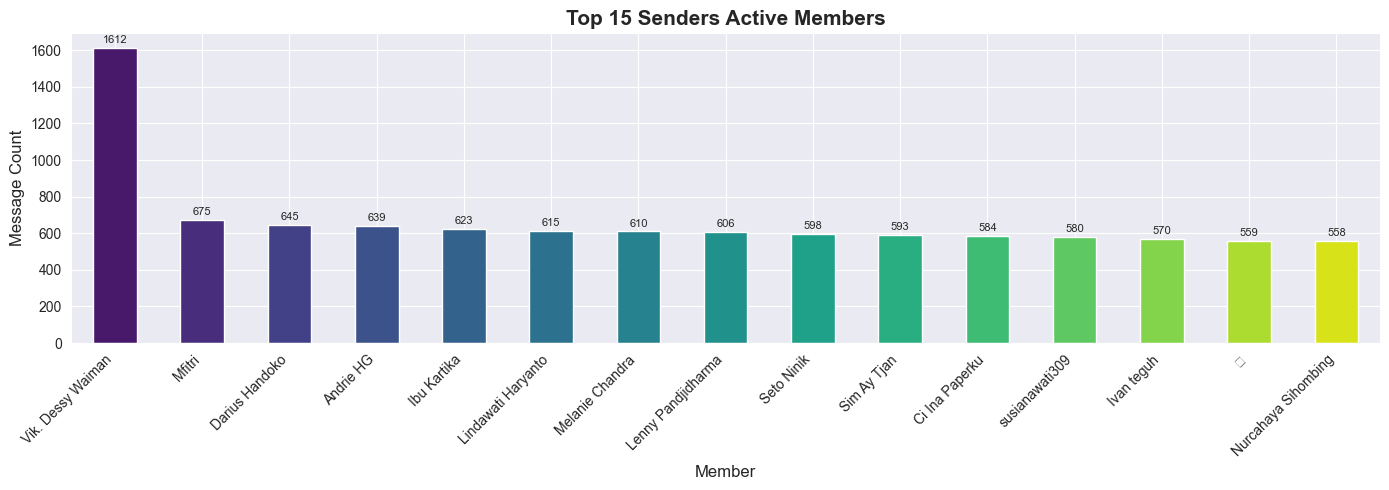

In [4]:
TOP_N = 15
sender_counts = df['sender'].value_counts().head(TOP_N)

ax = sender_counts.plot(kind='bar', color=sns.color_palette(PALETTE, TOP_N))
ax.set_title(f'Top {TOP_N} Senders Active Members')
ax.set_xlabel('Member')
ax.set_ylabel('Message Count')
ax.bar_label(ax.containers[0], fmt='%d', fontsize=8, padding=2)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 2.2 Daily Message Volume

**Purpose**  
Understand how message activity fluctuates over time.

In [5]:
messages_per_day = df.groupby(df['timestamp'].dt.date).size()

desc = messages_per_day.describe()
print(f"Mean   : {desc['mean']:.1f} messages/day")
print(f"Median : {desc['50%']:.1f} messages/day")
print(f"Max    : {int(desc['max'])} messages/day")
print(f"Min    : {int(desc['min'])} messages/day")

Mean   : 27.5 messages/day
Median : 28.0 messages/day
Max    : 86 messages/day
Min    : 1 messages/day


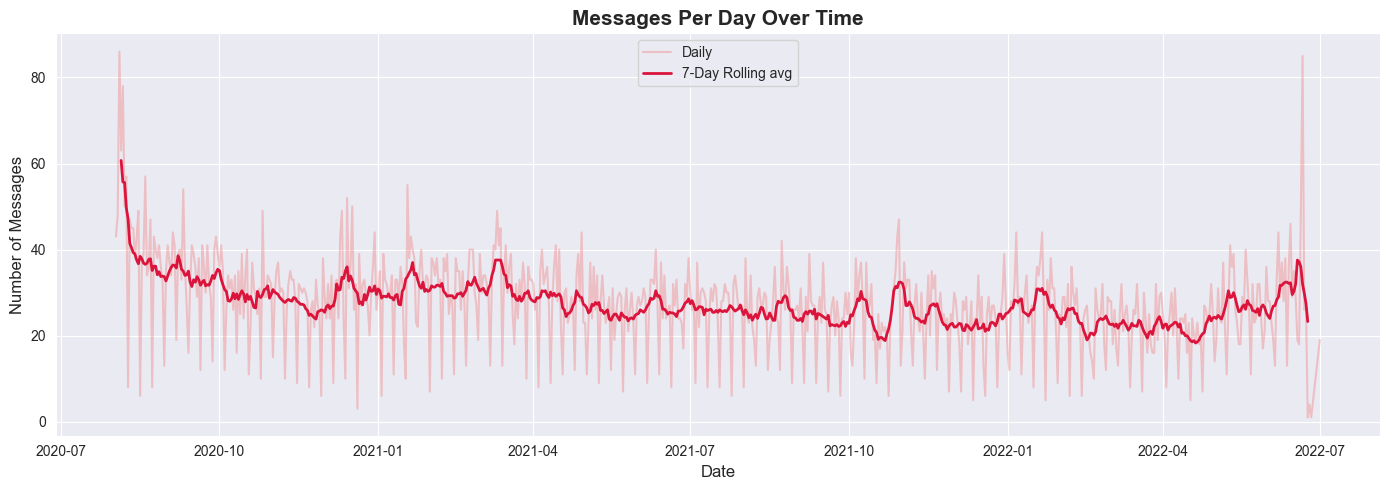

In [6]:
rolling7 = messages_per_day.rolling(window=7, center=True).mean()

plt.plot(messages_per_day.index, messages_per_day.values, 
         color='lightcoral', alpha=0.4, label='Daily')
plt.plot(rolling7.index, rolling7.values, 
         color='crimson', linewidth=2, label='7-Day Rolling avg')
plt.title('Messages Per Day Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Messages')
plt.legend()
plt.tight_layout()
plt.show()

### 2.3 Messages by Hour of Day

**Purpose**  
Discover the most active hours in the group.

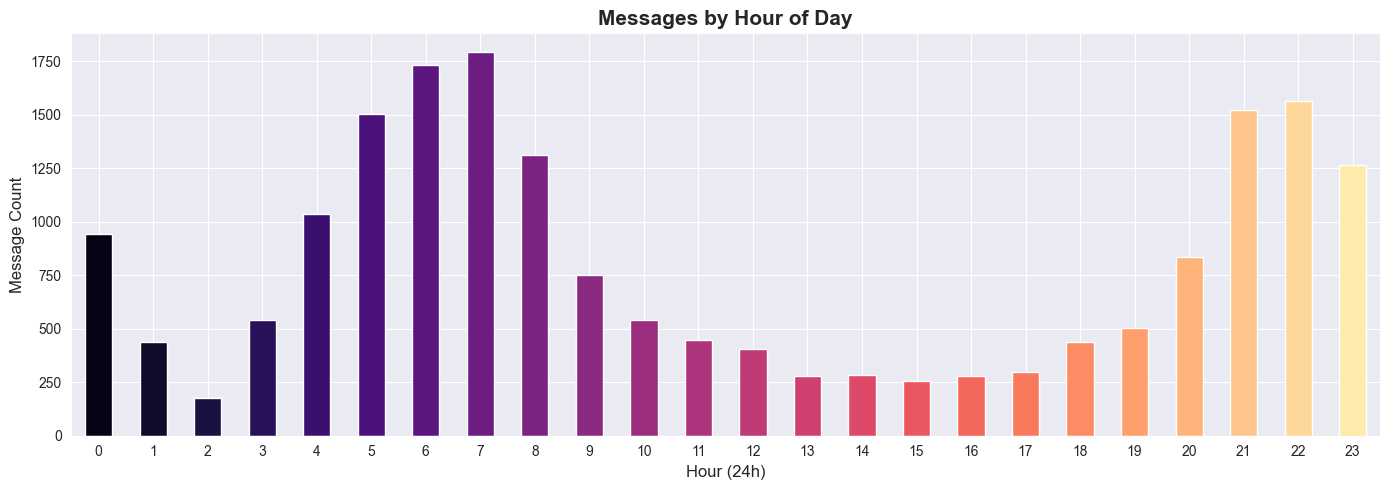

In [7]:
messages_per_hour = df.groupby(df['timestamp'].dt.hour).size()

ax = messages_per_hour.plot(kind='bar', color=sns.color_palette('magma', 24))
plt.title('Messages by Hour of Day')
plt.xlabel('Hour (24h)')
plt.ylabel('Message Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 2.4 Activity Heatmap - Hour x Day of Week

**Purpose**  
Provide a 2D view of *when* the group is most active.

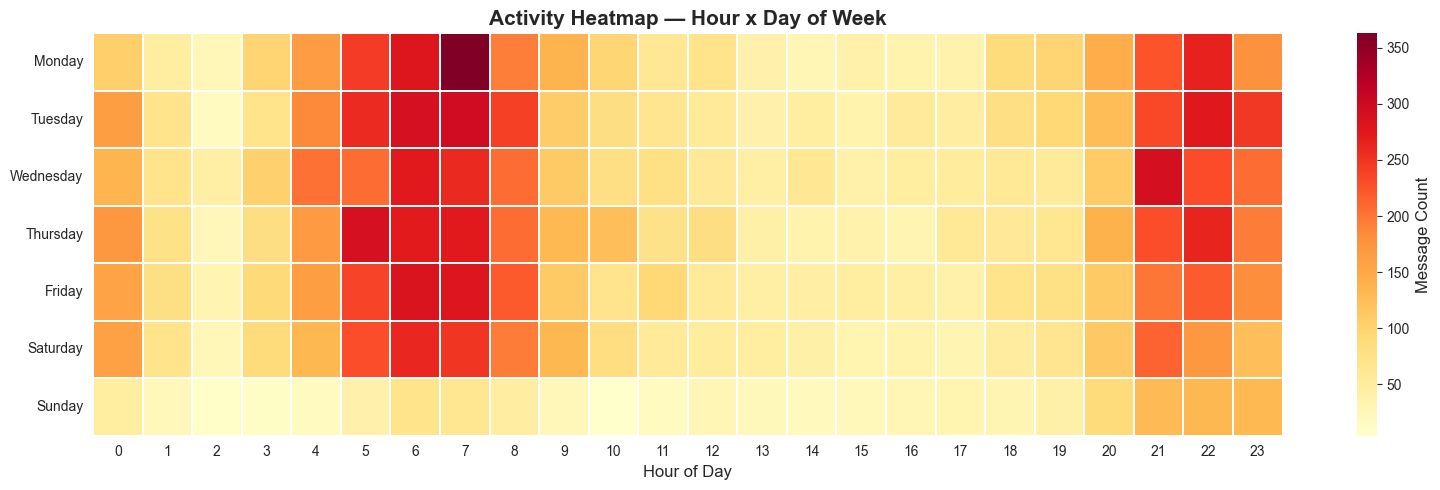

In [8]:
heatmap_data = (
    df
    .assign(
        hour=df['timestamp'].dt.hour,
        weekday=df['timestamp'].dt.day_name(),
    )
    .groupby(['weekday', 'hour'])
    .size()
    .unstack(fill_value=0)
    .reindex(DAYS_ORDER)
)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Message Count'})
ax.set_title('Activity Heatmap — Hour x Day of Week')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 2.5 Message Length Distribution

**Purpose**  
Understand communication style in the group.

In [9]:
message_lengths = df['message'].str.len()

print(f'Mean   : {message_lengths.mean():.2f} chars')
print(f'Median : {message_lengths.median():.2f} chars')
print(f'Std    : {message_lengths.std():.2f} chars')

Mean   : 147.29 chars
Median : 15.00 chars
Std    : 606.41 chars


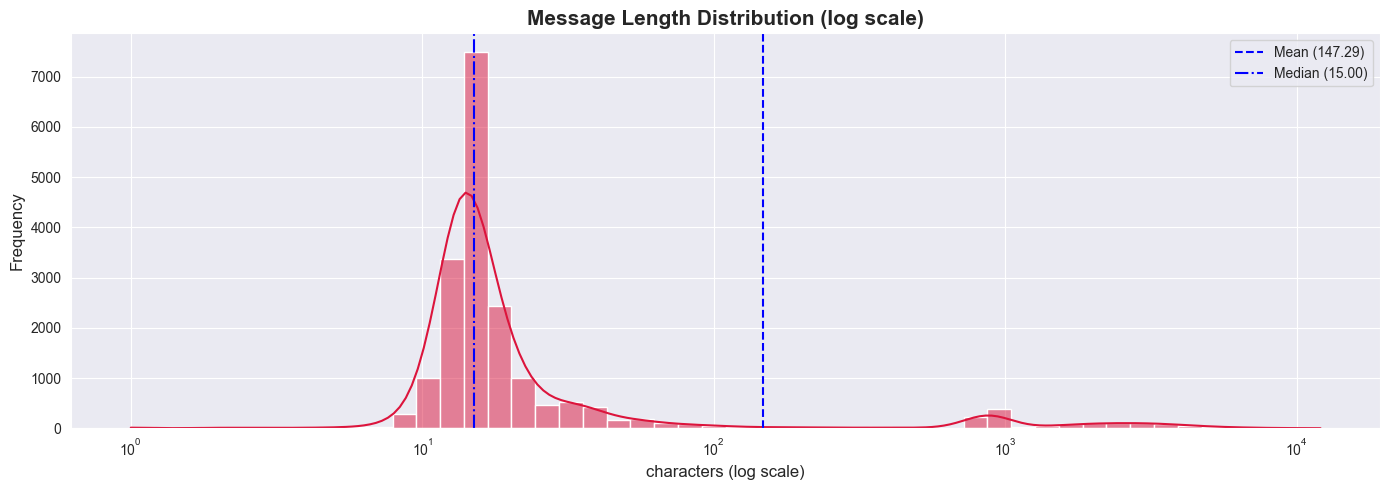

In [10]:
sns.histplot(message_lengths, bins=50, color='crimson', alpha=0.5, 
             kde=True, log_scale=True)
plt.axvline(np.mean(message_lengths), color='blue', linestyle='--', 
            label=f'Mean ({message_lengths.mean():.2f})')
plt.axvline(np.median(message_lengths), color='blue', linestyle='-.', 
            label=f'Median ({message_lengths.median():.2f})')

plt.title('Message Length Distribution (log scale)')
plt.xlabel('characters (log scale)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

### 2.6 Message Lines Distribution

**Purpose**  
Understand the structure of messages by analyzing how many lines each message contains.

In [11]:
num_lines = df['message'].str.count('\n') + 1

print(f'Mean   : {num_lines.mean():.2f} lines')
print(f'Median : {num_lines.median():.2f} lines')
print(f'Std    : {num_lines.std():.2f} lines')

Mean   : 3.88 lines
Median : 1.00 lines
Std    : 10.98 lines


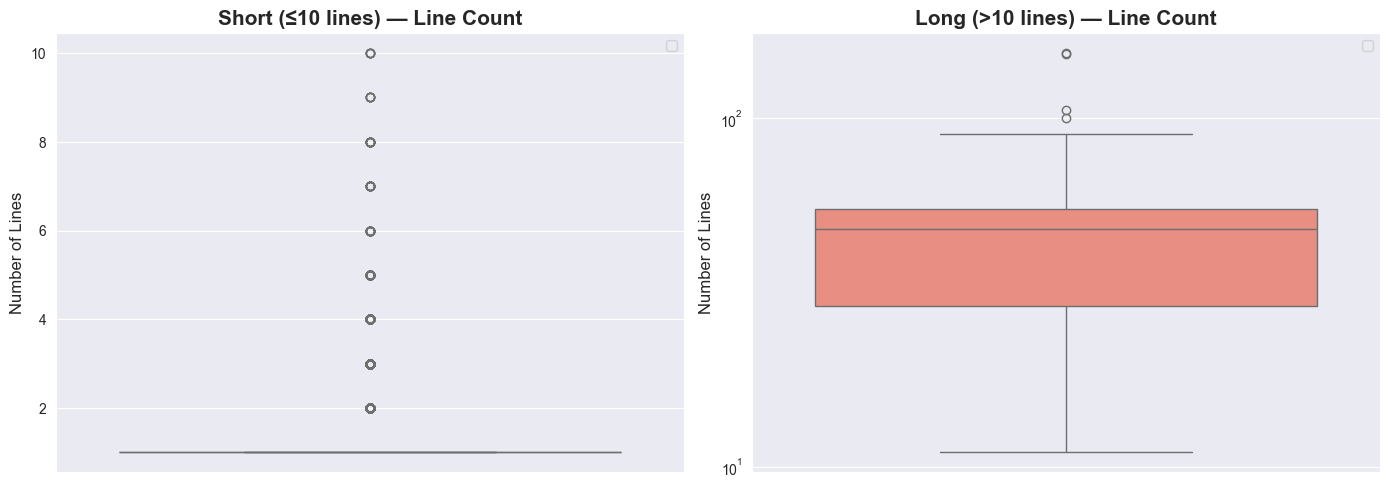

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, label, color, logscale in [
    (ax1, num_lines[num_lines <= 10], 'Short (≤10 lines)', 'skyblue', False),
    (ax2, num_lines[num_lines > 10],  'Long (>10 lines)',  'salmon',  True),
]:
    sns.boxplot(y=data, ax=ax, color=color)

    ax.set_title(f'{label} — Line Count')
    ax.set_ylabel('Number of Lines')

    if logscale:
        ax.set_yscale('log')

    ax.legend()

plt.tight_layout()
plt.show()

---
## 3. Pattern Analysis

Comparing progress messages against general messages to understand structural differences.

### 3.1 Message Length: Progress vs Non-Progress

**Hypothesis**  
Progress reports are typically short and structured. Non-progress reports messages cover casual chat, discussion, reflection, and question — so they could skew longer.

In [13]:
message_lengths = df['message'].str.len()
progress_lengths = message_lengths[df['is_progress']]
non_progress_lengths = message_lengths[~df['is_progress']]

print('Progress messages     — mean:', f'{progress_lengths.mean():.2f}',
      '  median:', f'{progress_lengths.median():.2f}')
print('Non-progress messages — mean:', f'{non_progress_lengths.mean():.2f}',
      '  median:', f'{non_progress_lengths.median():.2f}')

Progress messages     — mean: 17.19   median: 14.00
Non-progress messages — mean: 974.28   median: 426.00


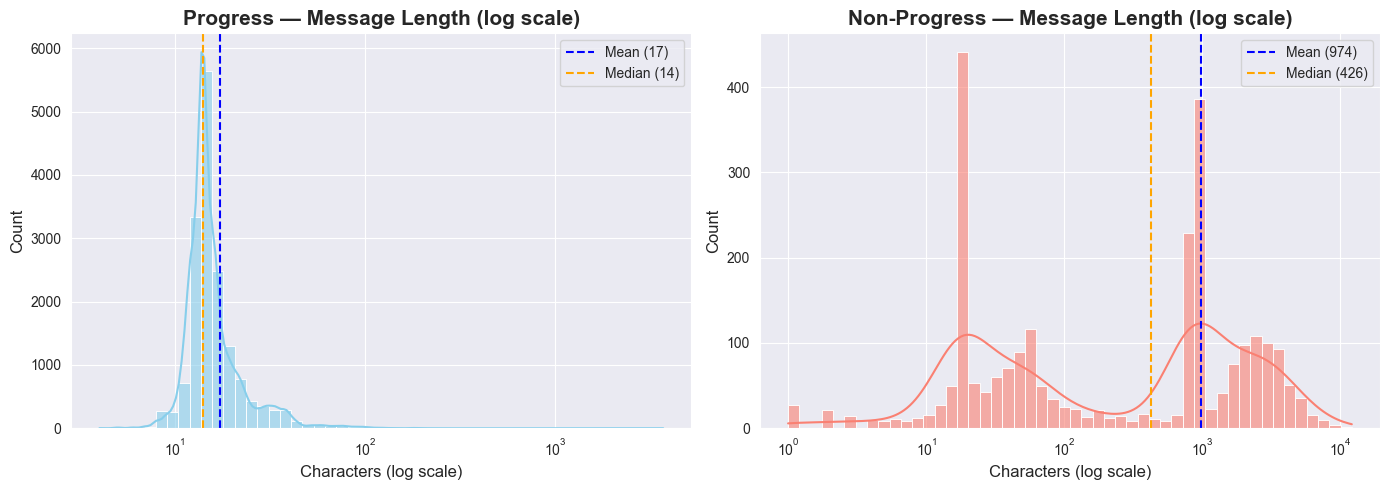

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, label, color in [
    (ax1, progress_lengths, 'Progress', 'skyblue'),
    (ax2, non_progress_lengths, 'Non-Progress', 'salmon'),
]:
    sns.histplot(data, bins=50, color=color, alpha=0.6, kde=True,
                 log_scale=True, ax=ax)
    ax.axvline(data.mean(),   color='blue',   linestyle='--', label=f'Mean ({data.mean():.0f})')
    ax.axvline(data.median(), color='orange', linestyle='--', label=f'Median ({data.median():.0f})')
    ax.set_title(f'{label} — Message Length (log scale)')
    ax.set_xlabel('Characters (log scale)')
    ax.legend()

plt.tight_layout()
plt.show()

### 3.2 Progress Reports by Member (Top 20)

**Purpose**  
Indetify the most committed readers by total report count.

In [15]:
progress_by_member = (
    df[df['is_progress']]
    .groupby('sender')
    .size()
    .sort_values(ascending=False)
)

top20 = progress_by_member.head(20)
print(top20.to_string())

sender
Mfitri                      657
Lindawati Haryanto          603
Andrie HG                   589
Seto Ninik                  588
Darius Handoko              584
Ci Ina Paperku              580
Melanie Chandra             578
susianawati309              570
Sim Ay Tjan                 567
Ivan teguh                  565
🎍                           550
Nurcahaya Sihombing         549
Dewi Pratiwi                537
Ibu Kartika                 536
Lenny Pandjidharma          536
Ruri Handoko                507
Endang Surati               461
Kristin WIjaya Nusantara    453
Agnes                       416
Tjunfebelyana               412


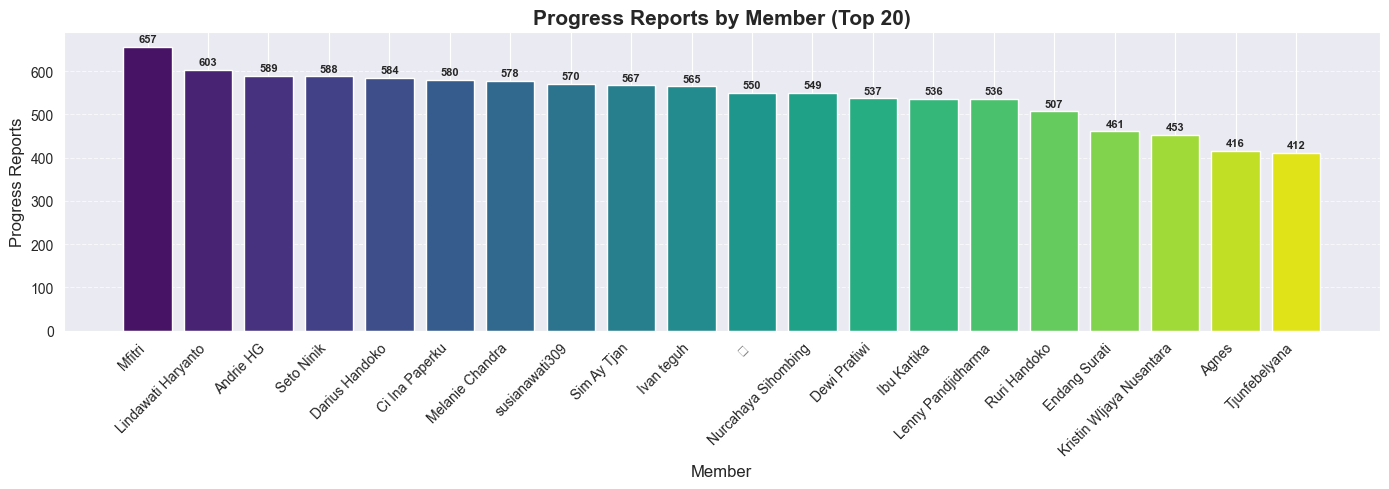

In [16]:
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(top20.index, top20.values,
              color=sns.color_palette(PALETTE, len(top20)))
ax.bar_label(bars, fmt='%d', fontsize=8, padding=2, fontweight='bold')
ax.set_title('Progress Reports by Member (Top 20)')
ax.set_xlabel('Member')
ax.set_ylabel('Progress Reports')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4.3 Member Consistency — Active Days vs Total Reports

**Purpose**  
Differentiate between:
- Prolific reporters → High total count
- Consistent reporters → Report across many distinct days

**Interpretation**

| # | Scenario | Meaning |
|---|---------|-------------|
| 1 | High reports + high active days | Consistent daily reader |
| 2 | High reports + low active days | Multiple reports in fewer days |
| 3 | Low reports + low active days | Occasional reader |
| 4 | Low reports + high active days | Passive reader - nearly impossible |

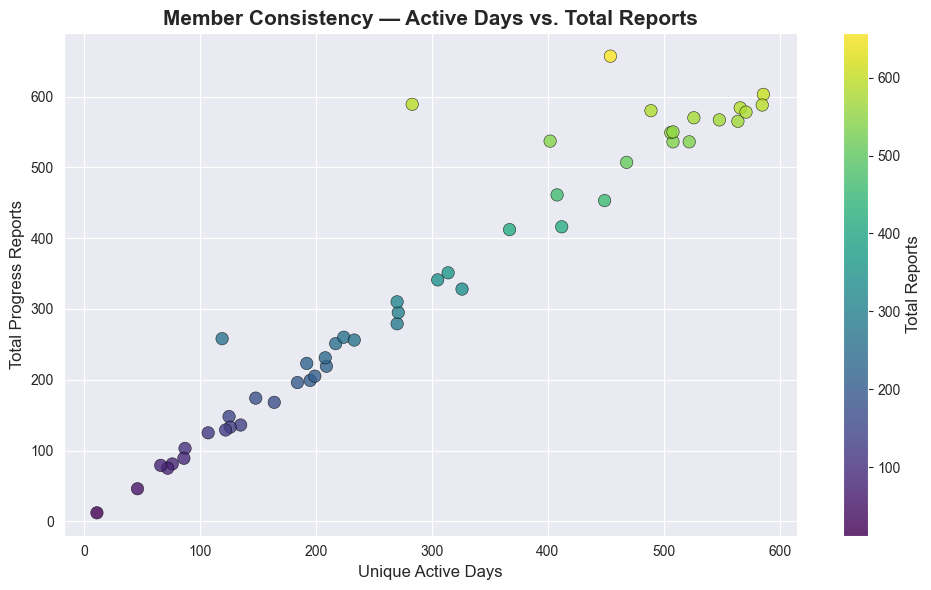

In [17]:
prog_df = df[df['is_progress']].copy()
prog_df['date'] = prog_df['timestamp'].dt.date

member_stats = prog_df.groupby('sender').agg(
    total_reports = ('message', 'count'),
    active_days = ('timestamp', lambda x: x.dt.date.nunique()),
).reset_index()

# onlt plot members with 5+ reports
plot_data = member_stats[member_stats['total_reports'] >= 5]

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    plot_data['active_days'], plot_data['total_reports'],
    c=plot_data['total_reports'], cmap=PALETTE, s=80, alpha=0.8,
    edgecolors='k', linewidths=0.4
)
plt.colorbar(sc, ax=ax, label='Total Reports')
ax.set_title('Member Consistency — Active Days vs. Total Reports')
ax.set_xlabel('Unique Active Days')
ax.set_ylabel('Total Progress Reports')
plt.tight_layout()
plt.show()

---
## 5. Temporal Trends

### 5.1 Monthly Message Volume

**Purpose**  
Understand long-term group activity and how progress reports track against overall message volume.

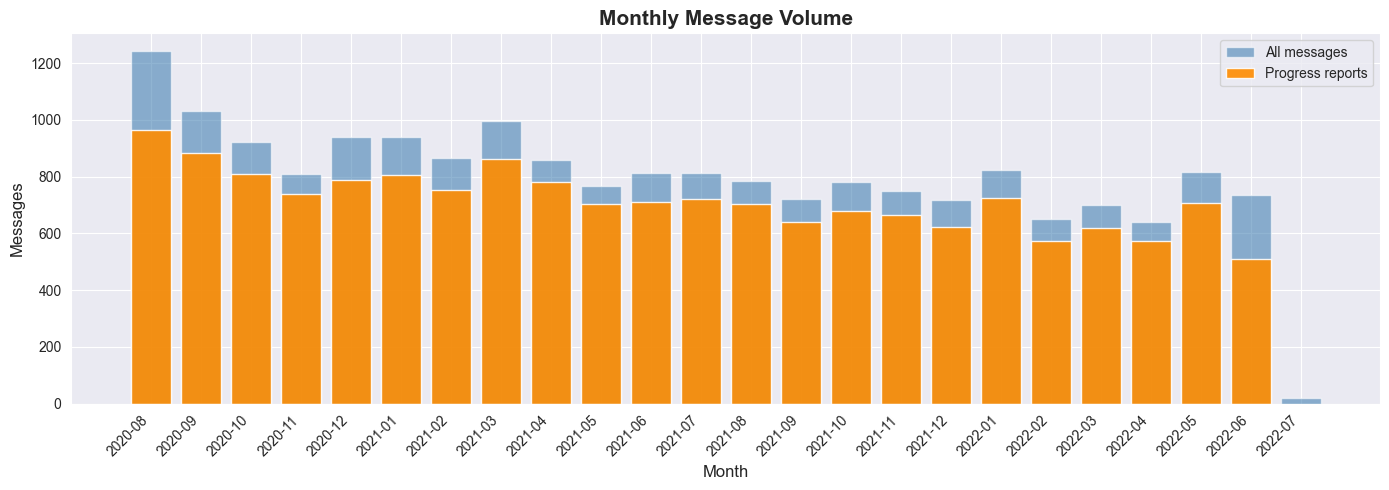

In [18]:
monthly_all = df.groupby(
    df['timestamp'].dt.to_period('M')
).size()

monthly_progress = df[df['is_progress']].groupby(
    df['timestamp'].dt.to_period('M')
).size()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly_all.index.astype(str),      monthly_all.values,
       color='steelblue', alpha=0.6, label='All messages')
ax.bar(monthly_progress.index.astype(str), monthly_progress.values,
       color='darkorange', alpha=0.9, label='Progress reports')
ax.set_title('Monthly Message Volume')
ax.set_xlabel('Month')
ax.set_ylabel('Messages')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5.2 Day-of-Week Reporting Pattern

**Purpose**  
Detect weekly rhythm in reading reports.

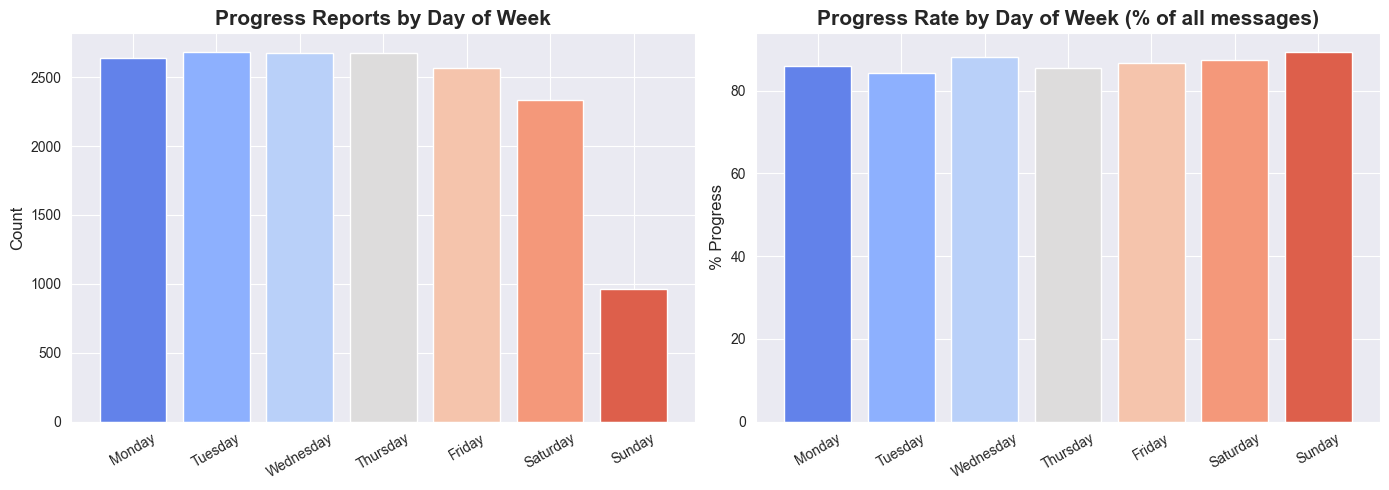

In [19]:
dow_all = (
    df
    .groupby(df['timestamp'].dt.day_name())
    .size()
    .reindex(DAYS_ORDER)
    )

dow_progress = (
    df[df['is_progress']]
    .groupby(df['timestamp'].dt.day_name())
    .size()
    .reindex(DAYS_ORDER)
)

dow_rate = (dow_progress / dow_all * 100).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(DAYS_ORDER, dow_progress.values, color=sns.color_palette('coolwarm', 7))
axes[0].set_title('Progress Reports by Day of Week')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(DAYS_ORDER, dow_rate.values, color=sns.color_palette('coolwarm', 7))
axes[1].set_title('Progress Rate by Day of Week (% of all messages)')
axes[1].set_ylabel('% Progress')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### Unique Active Members Over Time

**Purpose**  
Measure engagement breadth, not just volume

**Why it's Important**  
- Indicates community health
- Show retention vs decline
- Detect engagement expansion

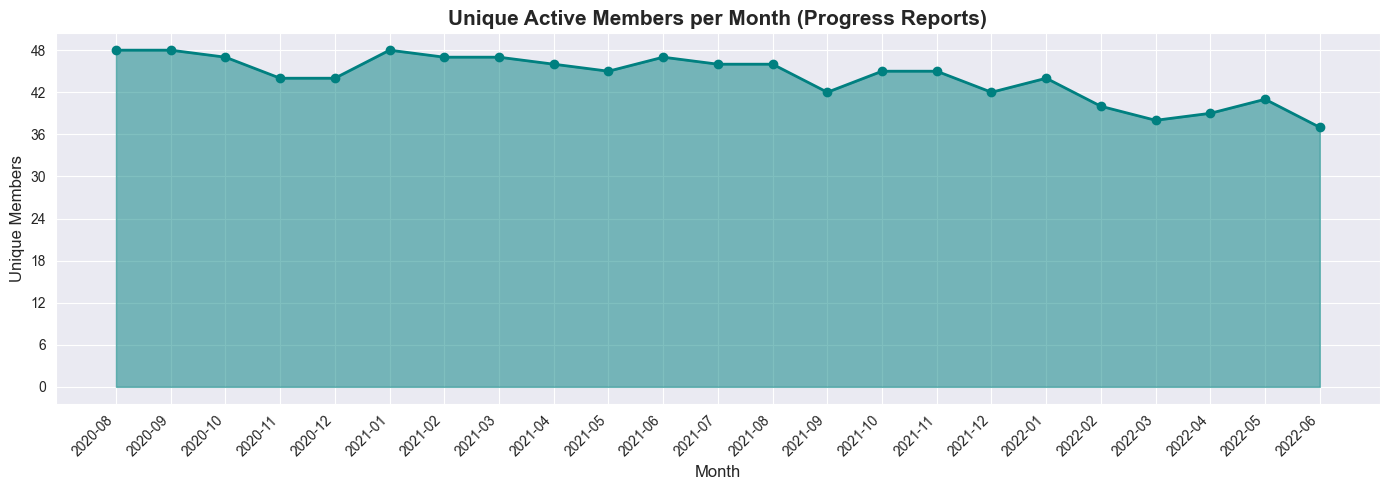

In [20]:
monthly_unique_members = (
    df[df['is_progress']]
    .groupby(df['timestamp'].dt.to_period('M'))['sender']
    .nunique()
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_unique_members.index.astype(str), 
        monthly_unique_members.values,
        marker='o', color='teal', linewidth=2)
ax.fill_between(monthly_unique_members.index.astype(str), 
                monthly_unique_members.values,
                alpha=0.5, color='teal')
ax.set_title('Unique Active Members per Month (Progress Reports)')
ax.set_xlabel('Month')
ax.set_ylabel('Unique Members')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 6. Export

**Objective**  
Prepare cleaned and/or filtered data for further NLP tasks.

| File | Contents |
|------|----------|
| `progress_messages.csv` | Progress reports only — used for NER and fine-tuning |
| `non_progress_messages.csv` | Non-progress messages |

In [21]:
exports = {
    'progress_messages.csv': df[df['is_progress']],
    'non_progress_messages.csv': df[~df['is_progress']],
}

for filename, df_out in exports.items():
    path = OUT_DIR / filename
    df_out.to_csv(path, index=False, encoding='utf-8-sig')
    print(f'Saved {len(df_out):>6,} rows → {filename}')

Saved 16,540 rows → progress_messages.csv
Saved  2,602 rows → non_progress_messages.csv
